# Reduced equations (analytic solution)

Let's plot the analytic solution for the reduced equations:

$$ 0 = \frac{\partial \mathcal{W}}{\partial t} = \frac{1}{\Sigma \Omega R^3 } \frac{\partial \mathcal{G}}{\partial R} - \left(\frac{\Omega_z^2 - \Omega^2}{\Omega^2} \right) \frac{i\Omega}2 \mathcal{W}.$$
$$ 0 = \frac{\partial \mathcal{G}}{\partial t} = \frac{\Sigma H^2 \Omega^3 R^3}4 \frac{\partial \mathcal{W}}{\partial R}  - \left( \frac{\kappa^2 - \Omega^2}{\Omega^2} \right) \frac{i\Omega}2 \mathcal{G} - \alpha \Omega \mathcal{G}, $$

This is the same system as the one in `reduced-eqs-zhu2019.ipynb` and `reduced-eqs-steady-state.ipynb`; i.e., a disk with one planet. In this notebook, I'll test our analytic solution (derived on 12/10/25) against our simulations.

# Imports and global parameters

In [116]:
import numpy as np
import pandas as pd
import tables
import time
import math
#import scipy.differentiate
import scipy.integrate as integ
import scipy.interpolate as interp

import matplotlib.pyplot as plt

In [117]:
cs = 0.02 # 0.02
h = cs
alpha = 0.01 # 0.1 # 0.019

# planet parameters
Mp, a = 0.003, 1

# toggle disk gap
use_gap = False

# gravitational softening term in disk potential
soft_term = 0.1

# radius of disk
Rout = 3.5
# radial coordinate of planet
a = 1
# outer boundary for planet's region of influence
delta = a * (2*soft_term)
Rminus = a - delta
Rplus = a + delta

# Analytic solution

In [118]:
def ycoord(R):
    '''
    Returns the dimensionless coordinate y(R), where 
    dy = Z(R)dR / ha.
    
    '''

    return Mp/(np.pi * soft_term * h) * \
        np.arctan(((R/a) - 1)/soft_term)
    

k = ycoord(Rplus)

In [119]:
Wout = 0.1

Win = (4j * (alpha/h) * (Rout**(1/2) - Rplus**(1/2))/a**(1/2) * (np.sinh(2*k)-1) \
        + np.sinh(2*k))**(-1) * Wout

Win

(0.07145482754625919-0.023248827906105714j)

In [120]:
Wminus = Win
Wplus = Wminus * np.sinh(2*k)
Wplus

(0.09042721848364157-0.029421760750776113j)

In [121]:
np.sinh(2*k)

np.float64(1.265515873299111)

In [122]:
def Winner(R):
    '''
    Compute W(R) in the inner region (i.e., R < R_minus).
    
    '''

    ones = np.zeros(np.shape(R)) + 1
    return Win*ones

def Wmid(R):
    '''
    Compute W(R) in the middle region; i.e., the planet's
    region of influence (R_minus < R < R_plus).
    
    '''

    k = ycoord(Rplus)
    c1 = (np.sinh(2*k) - 1) / (2 * np.sinh(k) * (1 + np.exp(-2*k))) * Win
    c2 = c1 * np.exp(-2*k)

    y = ycoord(R)
    return c1*np.exp(y) + c2*np.exp(-y)

def Wouter(R):
    '''
    Compute W(R) in the outer region (i.e., R > R_plus).
    
    '''

    return 4j * (alpha/h) * (R**(1/2) - Rplus**(1/2))/a**(1/2) * (Wplus-Wminus) \
            + Wplus

## plot $\mathcal{W}(R)$

In [123]:
# spatial domain
Rmin = 0.5
Rmax = 3.5
DeltaR = .03 # 0.03
num_Rs = (int) ((Rmax - Rmin) / DeltaR) + 1

# stagger W and G in the R domain
Rs_warp = np.linspace(Rmin, Rmax, num_Rs)

Rs_inner = Rs_warp[Rs_warp < Rminus]
Rs_outer = Rs_warp[Rs_warp > Rplus]
Rs_mid = Rs_warp[(Rs_warp > Rminus) & (Rs_warp < Rplus)]

In [124]:
Wplus - Wminus

(0.018972390937382386-0.006172932844670399j)

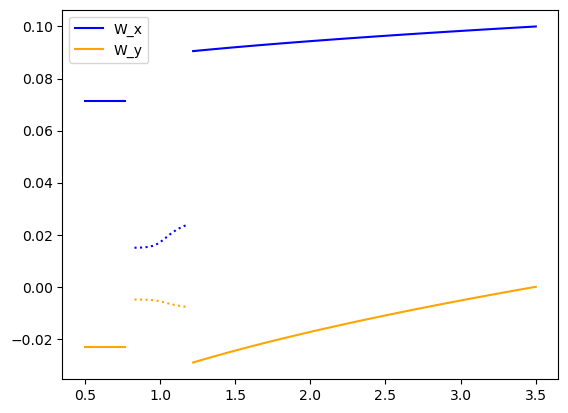

In [126]:
plt.plot(Rs_inner, Winner(Rs_inner).real, color="blue", ls='-')
plt.plot(Rs_inner, Winner(Rs_inner).imag, color="orange", ls='-')

plt.plot(Rs_mid, Wmid(Rs_mid).real, color="blue", ls=':')
plt.plot(Rs_mid, Wmid(Rs_mid).imag, color="orange", ls=':')

plt.plot(Rs_outer, Wouter(Rs_outer).real, color="blue", ls='-', label="W_x")
plt.plot(Rs_outer, Wouter(Rs_outer).imag, color="orange", ls='-', label="W_y")

plt.legend()
plt.show()